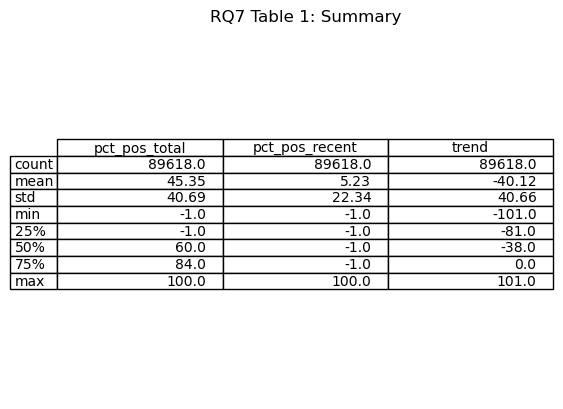

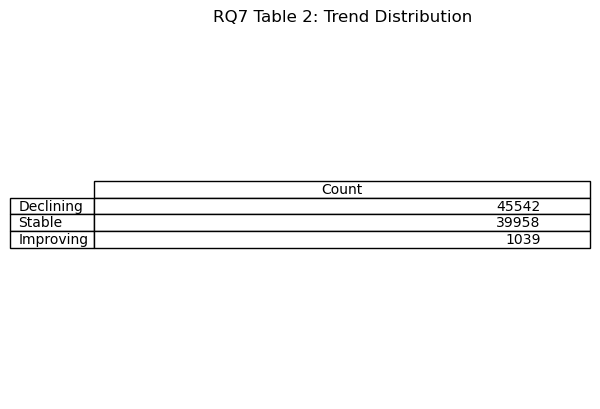

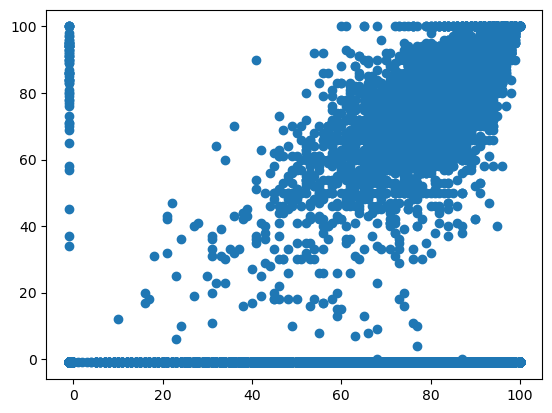

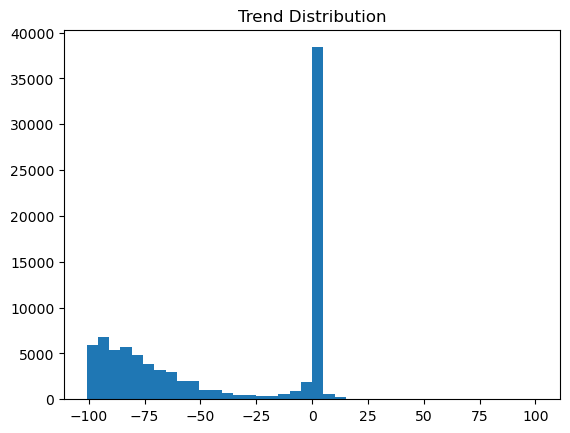

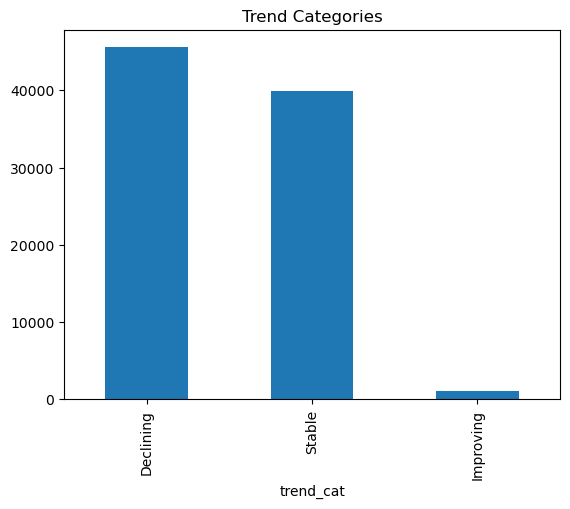

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('Tables', exist_ok=True)
os.makedirs('Models', exist_ok=True)

df = pd.read_csv(r'games_march2025_cleaned.csv')
df = df.drop_duplicates()

df['pct_pos_total'] = pd.to_numeric(df['pct_pos_total'], errors='coerce')
df['pct_pos_recent'] = pd.to_numeric(df['pct_pos_recent'], errors='coerce')

rq7 = df[['pct_pos_total','pct_pos_recent']].dropna()

rq7['trend'] = rq7['pct_pos_recent'] - rq7['pct_pos_total']

# ================= TABLE 1: SUMMARY =================
summary = rq7.describe()

plt.figure(); plt.axis('off')
plt.table(cellText=np.round(summary.values,2),
          colLabels=summary.columns,
          rowLabels=summary.index,
          loc='center')
plt.title('RQ7 Table 1: Summary')
plt.savefig('Tables/RQ7_Table1_Summary.png', dpi=300, bbox_inches='tight')
plt.show()

# ================= TABLE 2: TREND CATEGORY =================
rq7['trend_cat'] = pd.cut(rq7['trend'],
                         bins=[-100,-5,5,100],
                         labels=['Declining','Stable','Improving'])

trend_counts = rq7['trend_cat'].value_counts()

plt.figure(); plt.axis('off')
plt.table(cellText=trend_counts.values.reshape(-1,1),
          colLabels=['Count'],
          rowLabels=trend_counts.index,
          loc='center')
plt.title('RQ7 Table 2: Trend Distribution')
plt.savefig('Tables/RQ7_Table2_Trend.png', dpi=300, bbox_inches='tight')
plt.show()

# ================= FIGURES =================
plt.figure()
plt.scatter(rq7['pct_pos_total'], rq7['pct_pos_recent'])
plt.savefig('Models/RQ7_Fig1_Scatter.png', dpi=300)
plt.show()

plt.figure()
plt.hist(rq7['trend'], bins=40)
plt.title('Trend Distribution')
plt.savefig('Models/RQ7_Fig2_Hist.png', dpi=300)
plt.show()

plt.figure()
trend_counts.plot(kind='bar')
plt.title('Trend Categories')
plt.savefig('Models/RQ7_Fig3_Bar.png', dpi=300)
plt.show()
